# Conos walkthrough: integrating a panel of samples

**Conos** (Clustering On Network of Samples) jointly analyses a
*collection* of single-cell samples. Instead of merging all cells into
one matrix (which can bury real per-sample structure and amplify batch
effects), Conos aligns each *pair* of samples in a shared reduced space,
stitches their neighbourhoods into one weighted graph, and runs
clustering, embedding, and differential expression on that joint graph.
Cells of the same type connect across samples, while each sample keeps
its own structure.

This walkthrough takes the standard, minimal workflow end to end on a
small bone-marrow / cord-blood panel. It is deliberately bare — see the
[advanced tutorial](conos-advanced.ipynb) for alignment-space choices,
memory controls, and label-transfer options.

## Setup

We use the example panel from the `conosPanel` package and preprocess
each sample with `pagoda2`.

In [ ]:
library(conos)
library(pagoda2)
library(conosPanel)

panel <- conosPanel::panel        # a named list of 4 sparse count matrices (genes x cells)
str(panel, 1)

List of 4
 $ MantonBM1_HiSeq_1:Formal class 'dgCMatrix' [package "Matrix"] with 6 slots
 $ MantonBM2_HiSeq_1:Formal class 'dgCMatrix' [package "Matrix"] with 6 slots
 $ MantonCB1_HiSeq_1:Formal class 'dgCMatrix' [package "Matrix"] with 6 slots
 $ MantonCB2_HiSeq_1:Formal class 'dgCMatrix' [package "Matrix"] with 6 slots

To keep this tutorial quick to run we subsample each sample to ~1000
cells; in a real analysis you would use all of them.

In [ ]:
set.seed(1)
panel <- lapply(panel, function(m) m[, sample(ncol(m), min(1000, ncol(m)))])

A Conos panel is just a named list of count matrices — one per sample.
Cell names must be unique across the whole panel (so cells from
different samples never collide):

In [ ]:
any(duplicated(unlist(lapply(panel, colnames))))

[1] FALSE

## Preprocess each sample

Conos consumes per-sample objects that already have a PCA reduction. We
build one with the pagoda2.1 constructor `Pagoda2$from()` and run only
the reduction steps Conos needs — variance normalisation and PCA — with
`run(steps = ...)`. (Any `Pagoda2` or `Seurat` object carrying a
reduction works.) `run()` is thread/fork-safe, so set `n.cores` to your
machine.

In [ ]:
n.cores <- 4
preprocess <- function(cm) {
  rownames(cm) <- make.unique(rownames(cm))            # the panel has a few duplicate gene symbols
  p <- Pagoda2$from(cm, n.cores = n.cores, min.cells.per.gene = 0, min.transcripts.per.cell = 0,
                    log.scale = TRUE, verbose = FALSE)
  p$run(steps = c("variance", "pca"), dependencies = "error", verbose = FALSE)
  p
}
samples <- lapply(panel, preprocess)

## Build the Conos object and the joint graph

In [ ]:
con <- Conos$new(samples, n.cores = 1)

Before aligning, a quick sanity check of what the samples actually
share. `planIntegration()` reports, per modality, how many features are
common across samples and how well they overlap — for this
single-modality (RNA) panel it simply confirms a large shared gene set:

In [ ]:
con$planIntegration()

Integration plan — 4 samples

 modality samples common.features overlap.min overlap.med verdict
      RNA     4/4           33694           1           1  usable

common default modality: RNA — buildGraph() integrates on it

`runGraph()` aligns every pair of samples and assembles the joint graph.
The defaults are sensible: `space = "PCA"` uses **reciprocal PCA** (fast
and robust); `k` is the inter-sample neighbourhood size and `k.self` the
within-sample one.

In [ ]:
con$runGraph(k = 20, k.self = 5, space = "PCA", ncomps = 30, n.odgenes = 2000, verbose = FALSE)

## Cluster and embed

In [ ]:
con$runClustering(verbose = FALSE)                      # Leiden communities on the joint graph
con$runEmbedding(method = "largeVis", verbose = FALSE)  # a joint 2D embedding for visualisation

The joint embedding, coloured by the detected clusters:

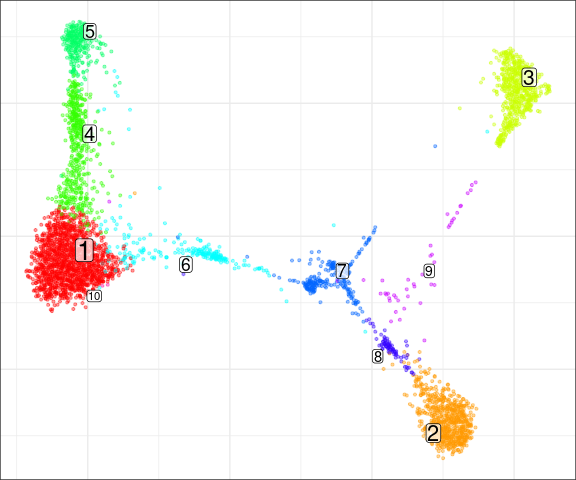

In [ ]:
con$plotGraph(clustering = "leiden")

The same clusters laid over each sample separately. Because the
clustering is *joint*, the same colours appearing in every sample is the
visual confirmation that populations are shared rather than
sample-specific:

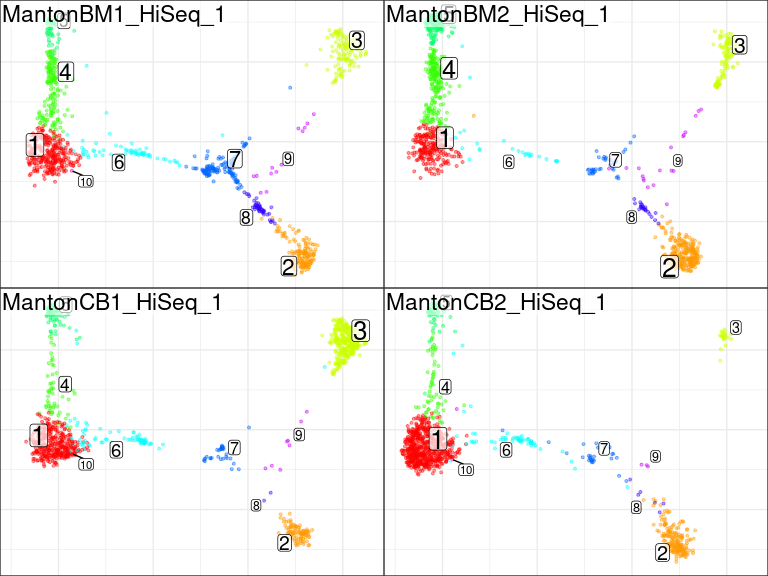

In [ ]:
con$plotPanel(clustering = "leiden", use.common.embedding = TRUE)

## Marker genes

`runMarkers()` finds genes differentially expressed between clusters;
`plotMarkerDotPlot()` shows the top few per cluster (dot size = fraction
of cells expressing, colour = scaled mean expression):

removed in the next pagoda2 version. Use `p2$runMarkers(...)` instead.
removed in the next pagoda2 version. Use `p2$runMarkers(...)` instead.
removed in the next pagoda2 version. Use `p2$runMarkers(...)` instead.
removed in the next pagoda2 version. Use `p2$runMarkers(...)` instead.

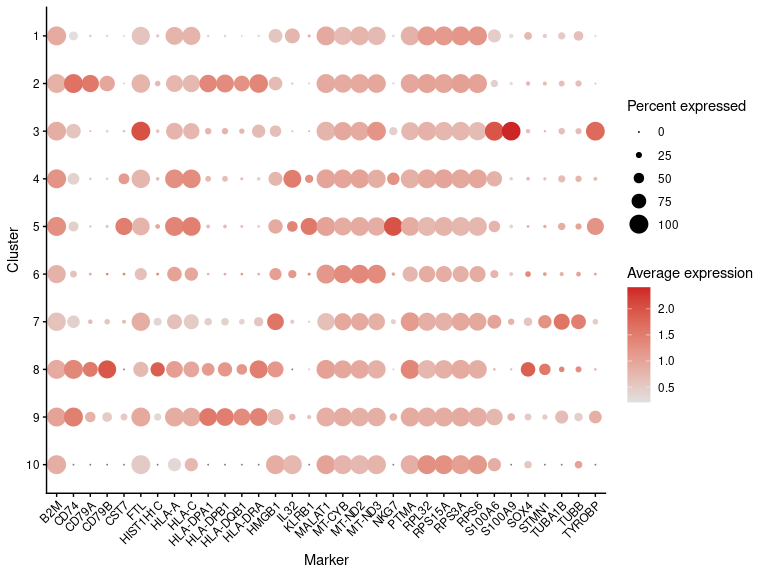

In [ ]:
con$plotMarkerDotPlot(n.genes.per.group = 4)

## Transferring annotations

A common task is to carry annotations from one (or a few) labelled
samples onto the rest. Here we *simulate* that by hiding the cluster
labels on a random 70% of cells and propagating from the remaining 30%
over the joint graph. `propagateLabels()` returns the transferred label
plus a per-cell uncertainty.

In [ ]:
groups <- con$clusters$leiden$groups
set.seed(1)
reference <- groups[sample(length(groups), round(0.30 * length(groups)))]   # a small "annotated" subset
transfer  <- con$propagateLabels(labels = reference, verbose = FALSE)

# how often the transferred label matches the original on the held-out cells:
held.out <- setdiff(names(groups), names(reference))
mean(transfer$labels[held.out] == as.character(groups[held.out]))

[1] 0.96

`transfer$labels` is the per-cell label and `transfer$uncertainty` a 0–1
confidence you can threshold or plot. On real data this recovers
held-out labels with high accuracy.

## Recap

The whole standard workflow is four calls on the Conos object:

``` r
con <- Conos$new(samples)
con$runGraph()        # align samples -> joint graph
con$runClustering()   # Leiden communities
con$runEmbedding()    # joint 2D embedding
```

plus `runMarkers()` / `plotMarkerDotPlot()` for markers and
`propagateLabels()` for annotation transfer. For controlling the
alignment (different spaces, memory, multimodal facets) continue to the
[advanced tutorial](conos-advanced.ipynb).